# Model descriptions

The Mitochondrial Retrograde (RTG) Signalling Model is a system of 11 coupled ODEs.

In [1]:
using RetroSignalModel
using ModelingToolkit

@named sys = RtgMTK(; simplify=false)

┌ Info: Precompiling RetroSignalModel [8bac15de-65a1-44a4-8b6e-7c4bf648ff0c]
└ @ Base loading.jl:1662


Model sys with 36 equations
States (36):
  Rtg2A_c(t)
  Rtg2Mks_c(t)
  BmhMks(t)
  Rtg13A_c(t)
  Rtg13I_c(t)
  Rtg3A_c(t)
⋮
Parameters (30):
  n_S [defaults to 1.0]
  ksV [defaults to 1.0]
  k2I [defaults to 1.0]
  ksD [defaults to 1.0]
  mul_S [defaults to 1.0]
  kn2M [defaults to 1.0]
⋮

## Parameter estimation

Simulated annealing (SAMIN) with bounds was used to find a set of parameters that fit exprerimental conditions.

[Source code](https://github.com/ntumitolab/RetroSignalModel.jl/blob/main/src/params.jl)

In [2]:
using RetroSignalModel
using Optim

optim_params(targetratio=2, optimoptions=Optim.Options(iterations=100, show_trace=true, show_every=10))

Iter     Function value   Gradient norm 
     0     3.010304e-01              NaN
 * time: 31.10527205467224
    10     3.010306e-01              NaN
 * time: 33.59766387939453
    20     6.922298e-01              NaN
 * time: 34.29135203361511
    30     3.507041e-01              NaN
 * time: 34.845494985580444
    40     3.501560e-01              NaN
 * time: 35.58637309074402
    50     5.455609e-01              NaN
 * time: 36.11997103691101
    60     5.459495e-01              NaN
 * time: 36.83245897293091
    70     8.103469e-01              NaN
 * time: 37.40064001083374
    80     7.999396e-01              NaN
 * time: 38.115010023117065
    90     7.808383e-01              NaN
 * time: 38.68662786483765
SAMIN results
NO CONVERGENCE: MAXEVALS exceeded

     Obj. value:           0.29581

       parameter      search width
         3.33029           5.00000 
       804.40887         999.99900 
       858.48192         999.99900 
       148.40605         999.99900 
        93.13

(res =  * Status: failure (reached maximum number of iterations)

 * Candidate solution
    Final objective value:     2.958068e-01

 * Found with
    Algorithm:     SAMIN

 * Convergence measures
    |x - x'|               = NaN ≰ 0.0e+00
    |x - x'|/|x'|          = NaN ≰ 0.0e+00
    |f(x) - f(x')|         = NaN ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = NaN ≰ 0.0e+00
    |g(x)|                 = NaN ≰ 0.0e+00

 * Work counters
    Seconds run:   39  (vs limit Inf)
    Iterations:    100
    f(x) calls:    100
    ∇f(x) calls:   0
, parammap = Dict{Sym{Real, Base.ImmutableDict{DataType, Any}}, Float64}(k3outA => 104.70160285394378, k3inA => 612.2331417809575, k13I => 205.81074524361608, kBM => 225.70405593563467, ksD => 148.4060468688242, k1in => 163.2222521157484, k3I_c => 322.28386448383617, k13IV => 815.0634053456588, k3A_c => 127.69204216478556, kn13_c => 644.9606492277871…))

## Valid parameter sets

In [3]:
using RetroSignalModel
using CSV
using DataFrames
using Plots

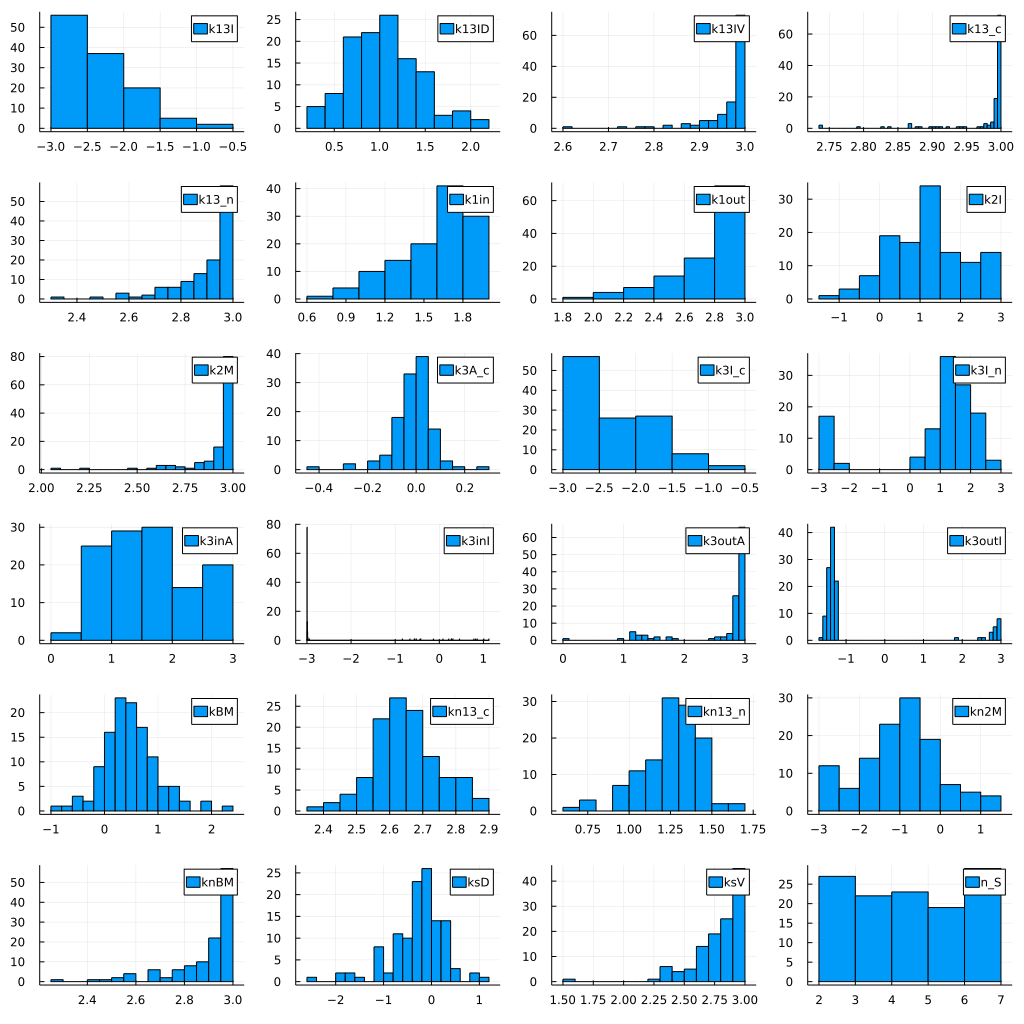

In [4]:
filename = joinpath(dirname(pathof(RetroSignalModel)), "data", "solution_rtgMTK_optim.csv")
dfoptim = let 
    df = CSV.read(filename, DataFrame)
    df[!, Not(:n_S)] .= log10.(df[!, Not(:n_S)])
end

res = map(sort(names(dfoptim))) do lab
    histogram(dfoptim[!, lab], label=lab)
end

plot(res..., layout=(6, 4), size=(1024, 1024))
# savefig("optimparams.png")

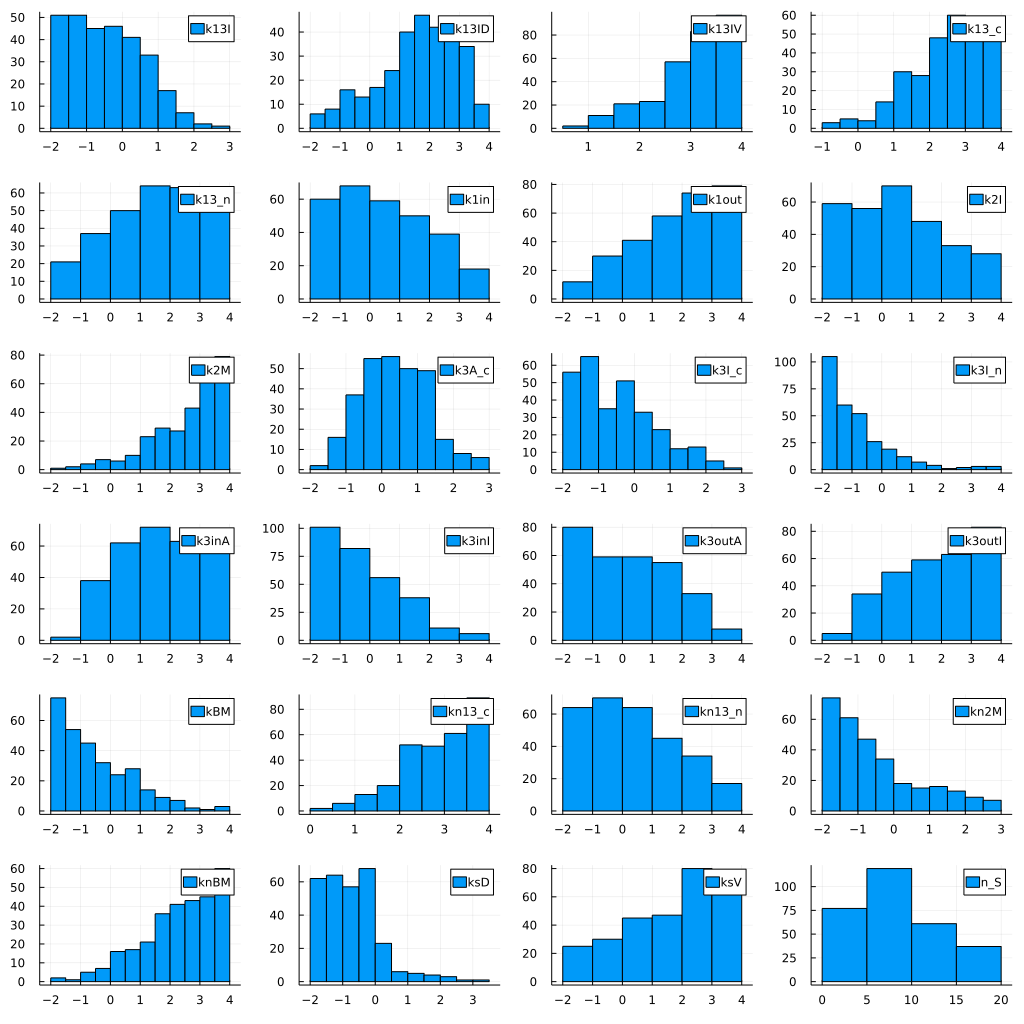

In [5]:
filename = joinpath(dirname(pathof(RetroSignalModel)), "data", "solution_rtgM4.csv")
dforig = let 
    df = CSV.read(filename, DataFrame)
    df[!, Not(:n_S)] .= log10.(df[!, Not(:n_S)])
end

res = map(sort(names(dforig))) do lab
    histogram(dforig[!, lab], label=lab)
end

plot(res..., layout=(6, 4), size=(1024, 1024))
# savefig("randomparams.png")